# ACC102 Mini Assignment - Track 2
## Risk-Return Comparison of AAPL, MSFT, and TSLA

Compare the risk and return profiles of Apple (AAPL), Microsoft (MSFT), and Tesla (TSLA) using daily stock price data from January 2020 to January 2025.

Data source: [Stooq](https://stooq.com/) free historical daily OHLCV data.

Metrics we will compute:
- Daily return and cumulative return
- Annualised return and volatility
- Sharpe Ratio (risk-free rate = 0)
- Maximum drawdown

In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

TICKERS = ["AAPL", "MSFT", "TSLA"]
CSV_FILES = {
    "AAPL": "aapl_us_d.csv",
    "MSFT": "msft_us_d.csv",
    "TSLA": "tsla_us_d.csv",
}
DATA_DIR = "data"
TRADING_DAYS = 252

## 1. Load Data

Read the CSV files downloaded from Stooq. Each file contains columns: Date, Open, High, Low, Close, Volume.

In [21]:
def load_data(tickers, csv_files, data_dir):
    """Read local CSV files downloaded from Stooq."""
    frames = {}
    for ticker in tickers:
        csv_path = os.path.join(data_dir, csv_files[ticker])
        df = pd.read_csv(csv_path)
        print(f"{ticker}: {len(df)} rows, columns={list(df.columns)}")
        frames[ticker] = df
    return frames

raw = load_data(TICKERS, CSV_FILES, DATA_DIR)
raw["AAPL"].head()

AAPL: 1258 rows, columns=['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
MSFT: 1258 rows, columns=['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
TSLA: 1258 rows, columns=['Date', 'Open', 'High', 'Low', 'Close', 'Volume']


,Date,Open,High,Low,Close,Volume
0,2020-01-02,71.4084,72.4606,71.1545,72.4006,140681710
1,2020-01-03,71.6304,72.4567,71.4724,71.6990,151973851
2,2020-01-06,70.8160,72.3055,70.5707,72.2661,122979354
3,2020-01-07,72.2759,72.5340,71.7108,71.9297,115649091
4,2020-01-08,71.6322,73.3858,71.6304,73.0857,137276166


## 2. Data Cleaning

- Convert Date to datetime and set as index
- Remove duplicate dates
- Forward-fill any missing values

In [22]:
def clean_data(df, ticker):
    """Parse dates, drop duplicates, handle missing values."""
    df = df.copy()
    if "Date" not in df.columns:
        for col in df.columns:
            if "date" in col.lower():
                df.rename(columns={col: "Date"}, inplace=True)
                break

    df["Date"] = pd.to_datetime(df["Date"])
    df.sort_values("Date", inplace=True)
    n_before = len(df)
    df.drop_duplicates(subset=["Date"], inplace=True)
    n_dup = n_before - len(df)

    n_missing = df.isnull().sum().sum()
    df.ffill(inplace=True)
    df.dropna(inplace=True)
    df.set_index("Date", inplace=True)

    print(f"{ticker}: removed {n_dup} duplicates, "
          f"filled {n_missing} missing values, final rows = {len(df)}")
    return df

cleaned = {}
for ticker, df in raw.items():
    cleaned[ticker] = clean_data(df, ticker)

for t, df in cleaned.items():
    print(f"  {t}: {df.index.min().date()} to {df.index.max().date()}")

AAPL: removed 0 duplicates, filled 0 missing values, final rows = 1258
MSFT: removed 0 duplicates, filled 0 missing values, final rows = 1258
TSLA: removed 0 duplicates, filled 0 missing values, final rows = 1258
  AAPL: 2020-01-02 to 2024-12-31
  MSFT: 2020-01-02 to 2024-12-31
  TSLA: 2020-01-02 to 2024-12-31


## 3. Compute Risk-Return Metrics

For each stock we calculate:
- **Daily Return:** r_t = P_t / P_{t-1} - 1
- **Annualised Return:** mean daily return x 252
- **Annualised Volatility:** daily std x sqrt(252)
- **Sharpe Ratio:** annualised return / annualised volatility
- **Max Drawdown:** largest peak-to-trough decline

In [23]:
def compute_metrics(price_series, ticker):
    """Return a dict of key risk-return metrics."""
    daily_ret = price_series.pct_change().dropna()

    ann_return = daily_ret.mean() * TRADING_DAYS
    ann_vol = daily_ret.std() * np.sqrt(TRADING_DAYS)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan
    max_dd = (price_series / price_series.cummax() - 1).min()
    cumulative_return = (price_series.iloc[-1] / price_series.iloc[0]) - 1

    metrics = {
        "Ticker": ticker,
        "Cumulative Return": f"{cumulative_return:.2%}",
        "Annualised Return": f"{ann_return:.2%}",
        "Annualised Volatility": f"{ann_vol:.2%}",
        "Sharpe Ratio (Rf=0)": f"{sharpe:.2f}",
        "Max Drawdown": f"{max_dd:.2%}",
    }
    return metrics, daily_ret

all_metrics = []
returns_dict = {}
for ticker, df in cleaned.items():
    metrics, daily_ret = compute_metrics(df["Close"], ticker)
    all_metrics.append(metrics)
    returns_dict[ticker] = daily_ret

summary = pd.DataFrame(all_metrics)
summary

,Ticker,Cumulative Return,Annualised Return,Annualised Volatility,Sharpe Ratio (Rf=0),Max Drawdown
0,AAPL,244.00%,29.79%,31.68%,0.94,-31.43%
1,MSFT,174.39%,24.89%,30.49%,0.82,-37.15%
2,TSLA,1307.89%,75.53%,67.18%,1.12,-73.63%


## 4. Visualisation
### 4.1 Normalised Closing Price (Base = 100)

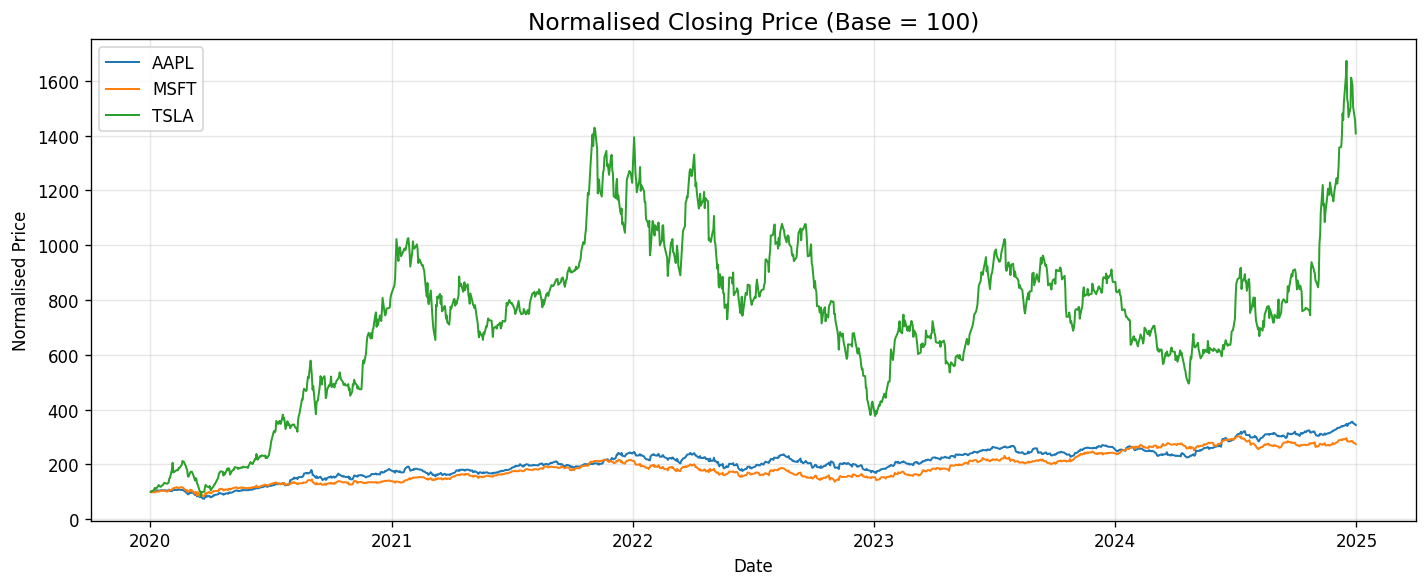

In [24]:
fig, ax = plt.subplots(figsize=(12, 5))
for ticker, df in cleaned.items():
    norm = df["Close"] / df["Close"].iloc[0] * 100
    ax.plot(norm.index, norm.values, label=ticker, linewidth=1.2)
ax.set_title("Normalised Closing Price (Base = 100)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Normalised Price")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("output/price_trend.png", dpi=150)
plt.show()

### 4.2 Daily Return Distribution

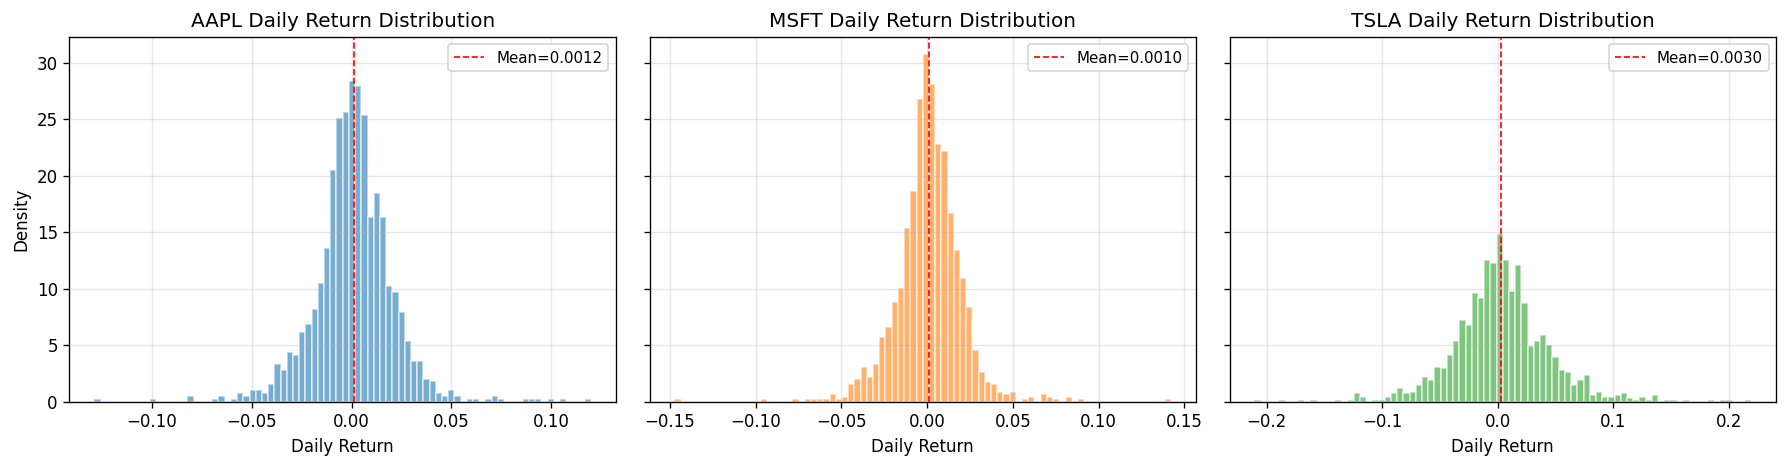

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
for ax, (ticker, ret), color in zip(axes, returns_dict.items(), colors):
    ax.hist(ret, bins=80, density=True, alpha=0.6, color=color, edgecolor="white")
    ax.set_title(f"{ticker} Daily Return Distribution", fontsize=12)
    ax.set_xlabel("Daily Return")
    ax.axvline(ret.mean(), color="red", linestyle="--", linewidth=1,
                label=f"Mean={ret.mean():.4f}")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Density")
plt.tight_layout()
plt.savefig("output/return_distribution.png", dpi=150)
plt.show()

### 4.3 Cumulative Return

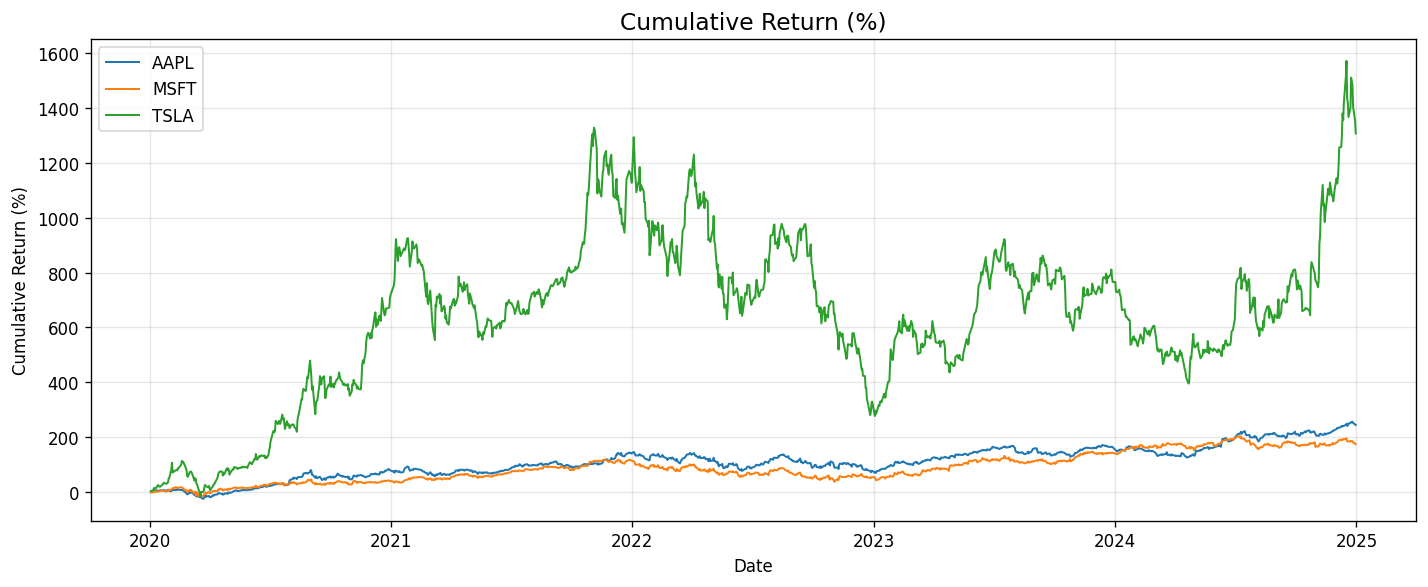

In [26]:
fig, ax = plt.subplots(figsize=(12, 5))
for ticker, ret in returns_dict.items():
    cum = (1 + ret).cumprod() - 1
    ax.plot(cum.index, cum.values * 100, label=ticker, linewidth=1.2)
ax.set_title("Cumulative Return (%)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return (%)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("output/cumulative_return.png", dpi=150)
plt.show()

### 4.4 Risk-Return Scatter Plot

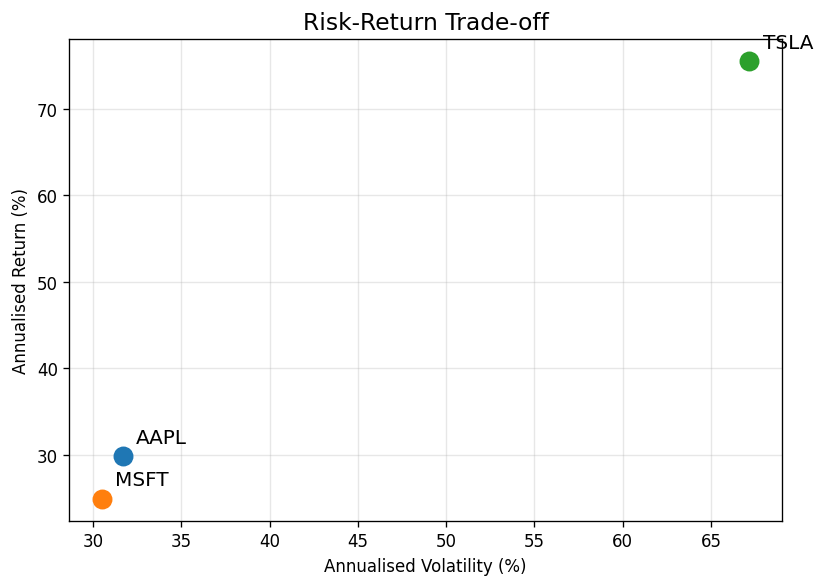

In [27]:
fig, ax = plt.subplots(figsize=(7, 5))
x = summary["Annualised Volatility"].str.rstrip("%").astype(float)
y = summary["Annualised Return"].str.rstrip("%").astype(float)
tickers = summary["Ticker"].tolist()
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
for i, t in enumerate(tickers):
    ax.scatter(x.iloc[i], y.iloc[i], s=120, color=colors[i], zorder=5)
    ax.annotate(t, (x.iloc[i], y.iloc[i]),
                textcoords="offset points", xytext=(8, 8), fontsize=12)
ax.set_title("Risk-Return Trade-off", fontsize=14)
ax.set_xlabel("Annualised Volatility (%)")
ax.set_ylabel("Annualised Return (%)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("output/risk_return_scatter.png", dpi=150)
plt.show()

## 5. Conclusion

In [28]:
print("Risk-Return Summary (2020-01 to 2025-01)")
print(summary.to_string(index=False))

print()
print("Key Findings:")
print("1. TSLA has the highest cumulative return but also the highest")
print("   annualised volatility, a typical high-risk-high-reward stock.")
print("2. MSFT shows a balanced risk-return profile with relatively")
print("   low volatility and a decent Sharpe ratio.")
print("3. AAPL sits between the two, with moderate returns and risk.")
print("4. Risk-averse investors may prefer MSFT or AAPL;")
print("   risk-tolerant investors may lean toward TSLA.")

Risk-Return Summary (2020-01 to 2025-01)
Ticker Cumulative Return Annualised Return Annualised Volatility Sharpe Ratio (Rf=0) Max Drawdown
  AAPL           244.00%            29.79%                31.68%                0.94      -31.43%
  MSFT           174.39%            24.89%                30.49%                0.82      -37.15%
  TSLA          1307.89%            75.53%                67.18%                1.12      -73.63%

Key Findings:
1. TSLA has the highest cumulative return but also the highest
   annualised volatility, a typical high-risk-high-reward stock.
2. MSFT shows a balanced risk-return profile with relatively
   low volatility and a decent Sharpe ratio.
3. AAPL sits between the two, with moderate returns and risk.
4. Risk-averse investors may prefer MSFT or AAPL;
   risk-tolerant investors may lean toward TSLA.
